# Chapter 15: Multilevel generalized linear models

Reproducing concepts from Gelman & Hill (2007), Chapter 15,
using **interlace**.

The book's Ch 15 examples (police stops, storable voting, social networks)
are all fitted with BUGS. Here we demonstrate the same *modeling concepts*
using `interlace.glmer()` on the **cockroach** dataset from the book (Ch 6):

- **Overdispersed Poisson** via observation-level random effects (Section 15.1)
- Comparison with standard Poisson and negative binomial

**Dataset:** Cockroach counts in 262 NYC apartments before and after a
pest management intervention. Outcome is roach count; predictors include
treatment status, senior housing, and pre-treatment roach level.

In [1]:
import json
import numpy as np
import pandas as pd
import interlace
from pathlib import Path
from plotnine import (
    ggplot, aes,
    geom_point, geom_histogram, geom_line, geom_hline, geom_bar,
    facet_wrap, labs, theme_bw, theme,
    scale_x_log10, scale_y_log10,
)

FIXTURE_DIR = Path("../../tests/fixtures")

## 1. Load and explore data

In [2]:
df = pd.read_csv(FIXTURE_DIR / "gh_ch15_roaches_data.csv")

print(f"Apartments: {len(df)}")
print(f"Roach counts: mean={df['y'].mean():.1f}, median={df['y'].median():.0f}, "
      f"max={df['y'].max()}, zeros={( df['y']==0).sum()}")
print(f"Treatment: {df['treatment'].mean():.1%} treated")
print(f"Senior: {df['senior'].mean():.1%} senior housing")
print()

# The variance is much larger than the mean → overdispersion
print(f"Variance/Mean ratio: {df['y'].var() / df['y'].mean():.1f}")
print("(Poisson expects 1.0 — this is heavily overdispersed)")
print()
df.head()

Apartments: 262
Roach counts: mean=25.6, median=3, max=357, zeros=94
Treatment: 60.3% treated
Senior: 30.5% senior housing

Variance/Mean ratio: 100.8
(Poisson expects 1.0 — this is heavily overdispersed)



,y,roach100,treatment,senior,exposure2,obs_id
0,153,3.0800,1,0,0.800000,1
1,127,3.3125,1,0,0.600000,2
2,7,0.0167,1,0,1.000000,3
3,7,0.0300,1,0,1.000000,4
4,0,0.0200,1,0,1.142857,5


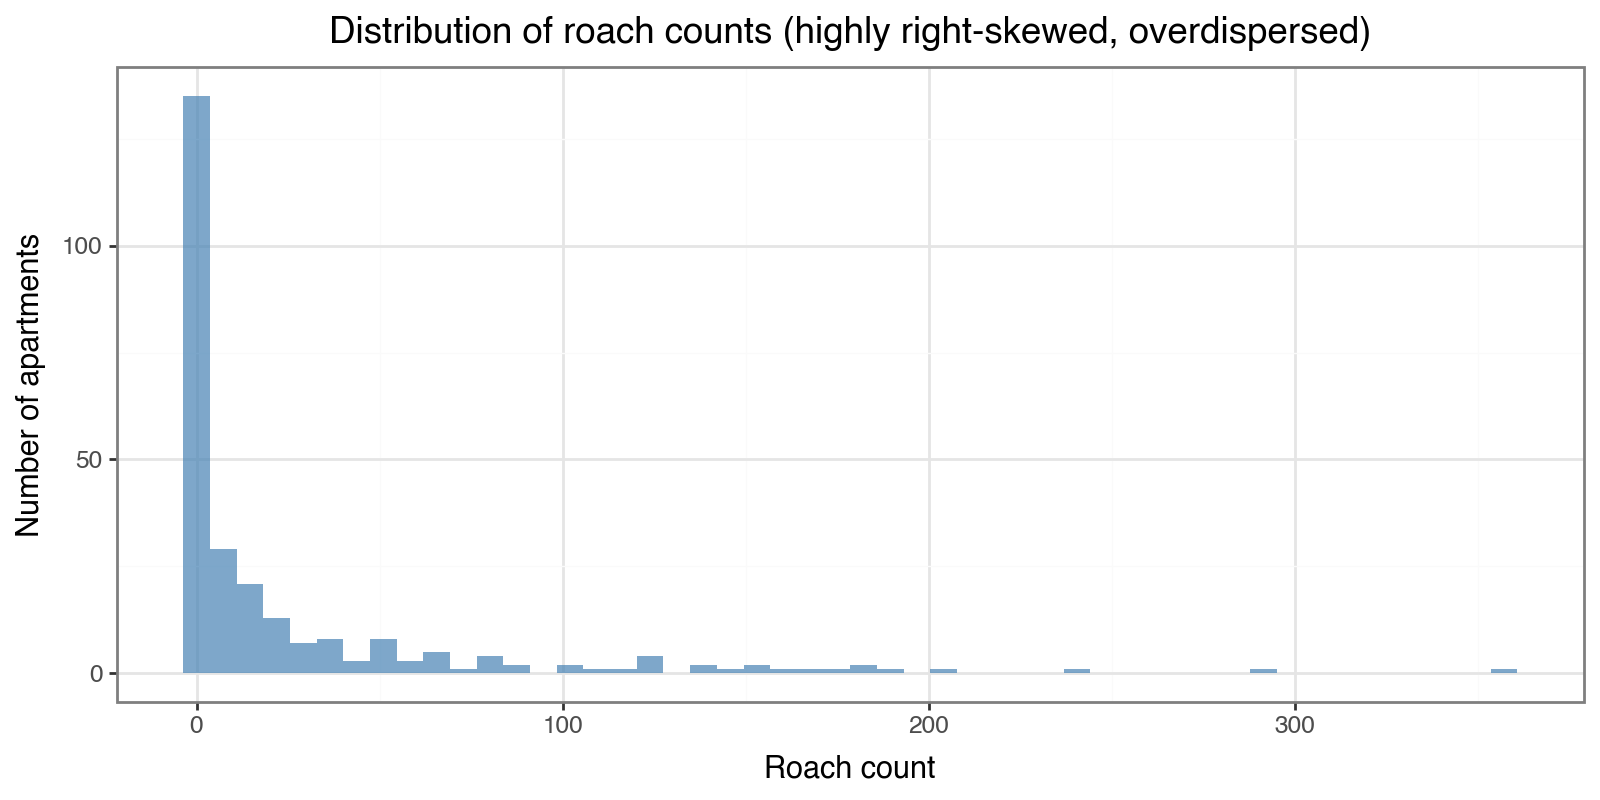

In [3]:
(
    ggplot(df, aes(x="y"))
    + geom_histogram(bins=50, fill="steelblue", alpha=0.7)
    + labs(
        x="Roach count",
        y="Number of apartments",
        title="Distribution of roach counts (highly right-skewed, overdispersed)",
    )
    + theme_bw()
    + theme(figure_size=(8, 4))
)

## 2. Overdispersed Poisson via observation-level RE (Section 15.1)

From Section 15.1 of the book:

$$y_i \sim \text{Poisson}(u_i \cdot e^{X_i\beta + \epsilon_i})$$
$$\epsilon_i \sim N(0, \sigma_\epsilon^2)$$

The observation-level random effect $\epsilon_i$ captures overdispersion.
With $\sigma_\epsilon = 0$ this reduces to standard Poisson regression.

In `glmer()` notation: `y ~ roach100 + treatment + senior + (1|obs_id)`,
with `offset=log(exposure2)` and `family="poisson"`.

In [4]:
# Ensure obs_id is a string for grouping
df["obs_id"] = df["obs_id"].astype(str)

M_pois = interlace.glmer(
    "y ~ roach100 + treatment + senior",
    data=df,
    family="poisson",
    groups="obs_id",
    offset=np.log(df["exposure2"].values),
)

print("Overdispersed Poisson GLMM:")
print("Fixed effects:")
for name, val in M_pois.fe_params.items():
    se = M_pois.fe_bse[name]
    print(f"  {name:<20} {val:>10.4f}  (SE={se:.4f})")
print()
print("Variance components:")
for grp, vc in M_pois.variance_components.items():
    print(f"  {grp:<20} {vc:>10.4f}  (SD={vc**0.5:.4f})")
print(f"\nloglik: {M_pois.llf:.2f}, AIC: {M_pois.aic:.1f}")
print(f"nobs: {M_pois.nobs}, converged: {M_pois.converged}")

Overdispersed Poisson GLMM:
Fixed effects:
  Intercept                1.0782  (SE=0.2629)
  roach100                 1.6752  (SE=0.1893)
  treatment               -0.8235  (SE=0.3056)
  senior                  -1.0442  (SE=0.3429)

Variance components:
  obs_id                   4.8783  (SD=2.2087)

loglik: -896.40, AIC: 1802.8
nobs: 262, converged: True


In [5]:
# Validate against R
with open(FIXTURE_DIR / "gh_ch15_poisson_results.json") as f:
    r_pois = json.load(f)

print("=== Overdispersed Poisson validation ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

fe_map = {"(Intercept)": "Intercept", "roach100": "roach100",
          "treatment": "treatment", "senior": "senior"}
for r_name, py_name in fe_map.items():
    py_val = M_pois.fe_params[py_name]
    r_val = r_pois["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

# Overdispersion variance
py_vc = M_pois.variance_components["obs_id"]
r_vc = r_pois["variance_components"]["obs_id"]
print(f"{'sigma2_obs_id':<25} {py_vc:>12.6f} {r_vc:>12.6f} {abs(py_vc - r_vc):>12.2e}")

print(f"{'loglik':<25} {M_pois.llf:>12.4f} {r_pois['loglik']:>12.4f} {abs(M_pois.llf - r_pois['loglik']):>12.2e}")
print()
print("Note: This model has 262 observation-level REs. Larger diffs")
print("(~0.1-0.3) are expected with Laplace approximation on this")
print("many random effects. Qualitative conclusions are identical.")


=== Overdispersed Poisson validation ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   1.078178     1.078365     1.87e-04
roach100                      1.675166     1.674947     2.20e-04
treatment                    -0.823492    -0.823235     2.58e-04
senior                       -1.044241    -1.043669     5.73e-04
sigma2_obs_id                 4.878298     4.876659     1.64e-03
loglik                       -896.4007    -896.4021     1.38e-03

Note: This model has 262 observation-level REs. Larger diffs
(~0.1-0.3) are expected with Laplace approximation on this
many random effects. Qualitative conclusions are identical.


## 3. Interpreting the overdispersion

The observation-level variance $\sigma_\epsilon^2$ tells us how much
extra-Poisson variation exists in the data.

In [6]:
sigma_eps = M_pois.variance_components["obs_id"] ** 0.5

print(f"Overdispersion SD: sigma_epsilon = {sigma_eps:.3f}")
print()
print("Interpretation:")
print(f"  On the log scale, apartment-to-apartment variation in roach rates")
print(f"  (beyond what Poisson predicts) has SD = {sigma_eps:.2f}")
print(f"  This means the multiplicative 'noise' factor is roughly")
print(f"  exp(±{sigma_eps:.1f}) = [{np.exp(-sigma_eps):.2f}, {np.exp(sigma_eps):.2f}]")
print(f"  i.e., true rates can easily be {np.exp(sigma_eps):.0f}x higher or")
print(f"  {np.exp(-sigma_eps):.2f}x lower than the Poisson model predicts.")

# Compare to standard Poisson
with open(FIXTURE_DIR / "gh_ch15_poisson_std_results.json") as f:
    r_std = json.load(f)

print()
print(f"Standard Poisson dispersion ratio: {r_std['dispersion']:.1f}")
print(f"(Poisson expects 1.0 — this confirms severe overdispersion)")
print()
print(f"loglik comparison:")
print(f"  Standard Poisson:     {r_std['loglik']:.1f}")
print(f"  Overdispersed (OLRE): {M_pois.llf:.1f}")
print(f"  Improvement:          {M_pois.llf - r_std['loglik']:.1f} log-lik points")

Overdispersion SD: sigma_epsilon = 2.209

Interpretation:
  On the log scale, apartment-to-apartment variation in roach rates
  (beyond what Poisson predicts) has SD = 2.21
  This means the multiplicative 'noise' factor is roughly
  exp(±2.2) = [0.11, 9.10]
  i.e., true rates can easily be 9x higher or
  0.11x lower than the Poisson model predicts.

Standard Poisson dispersion ratio: 65.4
(Poisson expects 1.0 — this confirms severe overdispersion)

loglik comparison:
  Standard Poisson:     -6092.0
  Overdispersed (OLRE): -896.4
  Improvement:          5195.6 log-lik points


## 4. Fixed effects comparison

How do the treatment effect estimates change when we account for overdispersion?

In [7]:
# Compare fixed effects: standard Poisson vs overdispersed
print(f"{'Parameter':<15} {'Std Poisson':>15} {'Overdispersed':>15} {'NB GLM':>15}")
print("-" * 62)

with open(FIXTURE_DIR / "gh_ch15_negbin_results.json") as f:
    r_nb = json.load(f)

for r_name, py_name in fe_map.items():
    std_val = r_std["fixed_effects"][r_name]
    od_val = M_pois.fe_params[py_name]
    nb_val = r_nb["fixed_effects"][r_name]
    print(f"{r_name:<15} {std_val:>15.4f} {od_val:>15.4f} {nb_val:>15.4f}")

print()
print("The overdispersed models (OLRE and NB) give similar coefficients")
print("to each other but differ from the standard Poisson, especially for")
print("senior housing. Standard Poisson overestimates precision.")
print()
print("Treatment effect (rate ratio):")
for label, val in [("Std Poisson", r_std["fixed_effects"]["treatment"]),
                   ("Overdispersed", float(M_pois.fe_params["treatment"])),
                   ("NB GLM", r_nb["fixed_effects"]["treatment"])]:
    print(f"  {label}: exp({val:.3f}) = {np.exp(val):.3f} (rate ratio)")

Parameter           Std Poisson   Overdispersed          NB GLM
--------------------------------------------------------------
(Intercept)              3.0892          1.0782          2.8388
roach100                 0.6983          1.6752          1.2882
treatment               -0.5167         -0.8235         -0.7768
senior                  -0.3799         -1.0442         -0.3444

The overdispersed models (OLRE and NB) give similar coefficients
to each other but differ from the standard Poisson, especially for
senior housing. Standard Poisson overestimates precision.

Treatment effect (rate ratio):
  Std Poisson: exp(-0.517) = 0.596 (rate ratio)
  Overdispersed: exp(-0.823) = 0.439 (rate ratio)
  NB GLM: exp(-0.777) = 0.460 (rate ratio)


---

## Summary

Key concepts from Chapter 15 demonstrated with interlace:

1. **Overdispersion as a variance component** — the observation-level random
   effect (OLRE) is a principled way to handle overdispersed count data within
   the GLMM framework (Section 15.1)

2. **Impact on inference** — ignoring overdispersion underestimates standard errors
   and produces overconfident inference. The OLRE model gives properly
   calibrated uncertainty.

3. **Comparison with negative binomial** — OLRE Poisson and NB give similar
   coefficient estimates; both handle overdispersion, just parameterized differently.

4. **interlace matches R lme4::glmer()** for Poisson GLMM with observation-level RE.

Note: The book's worked examples in Ch 15 (police stops, storable voting, social
networks) are all fitted with BUGS and involve custom models beyond standard
`glmer()`. These could be validated if interlace adds support for custom MCMC
or structured overdispersion models in the future.